# Model Improvement

Continuation of the main notebook: cross-validation, threshold optimization, hyperparameter tuning, feature re-selection, final locked model, and re-exported predictions.

## Rebuild dataset and features

In [1]:
"""
Model Improvement — steps 1-6 (lean version, tuned for a single-core sandbox)
1. Cross-validate current models (3-fold, patient-grouped, stratified)
2. Optimize decision threshold (reuses CatBoost OOF predictions from step 1)
3. Tune hyperparameters (small randomized search, CatBoost)
4. Re-run feature selection (drop low-importance features, compare CV PR-AUC)
5. Lock final model, evaluate once on held-out test set
6. Re-generate predictions + risk tiers
"""
import warnings, json, time
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT = "outputs"
T0 = time.time()
def log(msg):
    print(f"[{time.time()-T0:6.1f}s] {msg}", flush=True)

# =================================================================
# Rebuild the exact same cleaned dataset / features / split as pipeline.py
# =================================================================
df = pd.read_csv("data/diabetic_data.csv", na_values="?")
mapping_df = pd.read_csv("data/IDS_mapping.csv")
df["early_readmission"] = (df["readmitted"] == "<30").astype(int)

def build_mapping(mapping_df, key_col):
    col0 = mapping_df.iloc[:, 0].astype(str)
    start = 0 if key_col == mapping_df.columns[0] else mapping_df.index[col0 == key_col][0] + 1
    matches = mapping_df.index[(col0 == "discharge_disposition_id") | (col0 == "admission_source_id")]
    later = [i for i in matches if i > start]
    end = min(later) if later else len(mapping_df)
    sub = mapping_df.iloc[start:end]
    sub = sub[sub.iloc[:, 0].notna()]
    d = {}
    for _, row in sub.iterrows():
        try:
            d[int(float(row.iloc[0]))] = row.iloc[1]
        except (ValueError, TypeError):
            continue
    return d

df["admission_type"] = df["admission_type_id"].map(build_mapping(mapping_df, "admission_type_id"))
df["discharge_disposition"] = df["discharge_disposition_id"].map(build_mapping(mapping_df, "discharge_disposition_id"))
df["admission_source"] = df["admission_source_id"].map(build_mapping(mapping_df, "admission_source_id"))

df = df.drop(columns=["weight", "max_glu_serum"])
for c in ["A1Cresult", "medical_specialty", "payer_code", "race", "diag_1", "diag_2", "diag_3"]:
    df[c] = df[c].fillna("Unknown" if c != "A1Cresult" else "Not Tested")

expired_hospice_ids = [11, 13, 14, 19, 20, 21]
df = df[~df["discharge_disposition_id"].isin(expired_hospice_ids)].copy().reset_index(drop=True)

med_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
            "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
            "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
            "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone"]
med_cols = [c for c in med_cols if c in df.columns]
df["num_med_changes"] = (df[med_cols] == "Up").sum(axis=1) + (df[med_cols] == "Down").sum(axis=1)
df["num_meds_active"] = (df[med_cols] != "No").sum(axis=1)
df["total_prior_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]

def icd9_group(code):
    if code == "Unknown" or pd.isna(code):
        return "Unknown"
    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "Other"
    try:
        c = float(code)
    except ValueError:
        return "Other"
    if 390 <= c <= 459 or c == 785: return "Circulatory"
    if 460 <= c <= 519 or c == 786: return "Respiratory"
    if 520 <= c <= 579 or c == 787: return "Digestive"
    if 250 <= c < 251: return "Diabetes"
    if 800 <= c <= 999: return "Injury"
    if 710 <= c <= 739: return "Musculoskeletal"
    if 580 <= c <= 629 or c == 788: return "Genitourinary"
    if 140 <= c <= 239: return "Neoplasms"
    return "Other"

df["diag_1_group"] = df["diag_1"].apply(icd9_group)

def collapse_rare(series, min_count=1000, other_label="Other"):
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)

df["medical_specialty_grp"] = collapse_rare(df["medical_specialty"], 1000)
df["discharge_disposition_grp"] = collapse_rare(df["discharge_disposition"], 1000)
df["admission_source_grp"] = collapse_rare(df["admission_source"], 1000)

numerical_features = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                       "num_medications", "number_outpatient", "number_emergency",
                       "number_inpatient", "number_diagnoses"]
model_categorical = ["race", "gender", "age", "admission_type", "admission_source_grp",
                      "discharge_disposition_grp", "medical_specialty_grp",
                      "A1Cresult", "diag_1_group", "insulin", "change", "diabetesMed"]
model_numerical = numerical_features + ["num_med_changes", "num_meds_active", "total_prior_visits"]
feature_cols = model_categorical + model_numerical

X = df[feature_cols].copy()
y = df["early_readmission"].copy()
groups = df["patient_nbr"].copy()

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)
log(f"Train: {X_train.shape}, Test: {X_test.shape}")

def to_cb(Xdf):
    out = Xdf.copy()
    for c in model_categorical:
        if c in out.columns:
            out[c] = out[c].astype(str).fillna("Unknown")
    for c in model_numerical:
        if c in out.columns:
            out[c] = out[c].fillna(out[c].median())
    return out

X_train_cb = to_cb(X_train)
X_test_cb = to_cb(X_test)
cat_idx = [X_train_cb.columns.get_loc(c) for c in model_categorical]

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix, classification_report)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), model_numerical),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), model_categorical)
])

# ---------------------------------------------------------------
# 1) + 2) CROSS-VALIDATE + collect CatBoost OOF probabilities for threshold tuning
#    (3-fold, patient-grouped & stratified; single combined pass — single CPU core)
# ---------------------------------------------------------------
skf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = {"LogReg": {"roc": [], "pr": []}, "RandomForest": {"roc": [], "pr": []}, "CatBoost": {"roc": [], "pr": []}}
oof_proba = np.zeros(len(X_train))

for fold, (tr, va) in enumerate(skf.split(X_train, y_train, groups_train)):
    Xt, Xv = X_train.iloc[tr], X_train.iloc[va]
    yt, yv = y_train.iloc[tr], y_train.iloc[va]

    lr = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))])
    lr.fit(Xt, yt)
    p = lr.predict_proba(Xv)[:, 1]
    cv_results["LogReg"]["roc"].append(roc_auc_score(yv, p)); cv_results["LogReg"]["pr"].append(average_precision_score(yv, p))
    log(f"Fold {fold+1}/3 — LogReg done")

    rf = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=30, class_weight="balanced", random_state=42, n_jobs=-1))])
    rf.fit(Xt, yt)
    p = rf.predict_proba(Xv)[:, 1]
    cv_results["RandomForest"]["roc"].append(roc_auc_score(yv, p)); cv_results["RandomForest"]["pr"].append(average_precision_score(yv, p))
    log(f"Fold {fold+1}/3 — RandomForest done")

    Xt_cb, Xv_cb = to_cb(Xt), to_cb(Xv)
    pw = (yt == 0).sum() / (yt == 1).sum()
    cb = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.08, eval_metric="AUC",
                             scale_pos_weight=pw, random_seed=42, verbose=False)
    cb.fit(Xt_cb, yt, cat_features=cat_idx)
    p = cb.predict_proba(Xv_cb)[:, 1]
    oof_proba[va] = p
    cv_results["CatBoost"]["roc"].append(roc_auc_score(yv, p)); cv_results["CatBoost"]["pr"].append(average_precision_score(yv, p))
    log(f"Fold {fold+1}/3 — CatBoost done")

cv_summary = pd.DataFrame({
    m: {"ROC_AUC_mean": np.mean(v["roc"]), "ROC_AUC_std": np.std(v["roc"]),
        "PR_AUC_mean": np.mean(v["pr"]), "PR_AUC_std": np.std(v["pr"])}
    for m, v in cv_results.items()
}).T
log("=== 3-FOLD CV RESULTS (patient-grouped) ===")
print(cv_summary.round(4))
cv_summary.to_csv(f"{OUT}/cv_results.csv")

[   2.3s] Train: (79541, 23), Test: (19802, 23)


[   8.6s] Fold 1/3 — LogReg done


[  25.3s] Fold 1/3 — RandomForest done


[  45.2s] Fold 1/3 — CatBoost done


[  46.0s] Fold 2/3 — LogReg done


...

[  83.2s] Fold 3/3 — LogReg done


[  99.8s] Fold 3/3 — RandomForest done


[ 119.9s] Fold 3/3 — CatBoost done


[ 119.9s] === 3-FOLD CV RESULTS (patient-grouped) ===


              ROC_AUC_mean  ROC_AUC_std  PR_AUC_mean  PR_AUC_std
LogReg              0.6604       0.0127       0.2107      0.0095
RandomForest        0.6667       0.0131       0.2144      0.0112
CatBoost            0.6688       0.0105       0.2203      0.0086


## 2) THRESHOLD OPTIMIZATION using the CatBoost OOF probabilities above

[ 121.4s] === THRESHOLD SWEEP ===


Best F1 threshold:
 threshold    0.540000
precision    0.201803
recall       0.460211
f1           0.280574
Name: 13, dtype: float64

Highest-precision threshold with recall>=0.70:
    threshold  precision    recall        f1
9       0.42    0.15514  0.753242  0.257288


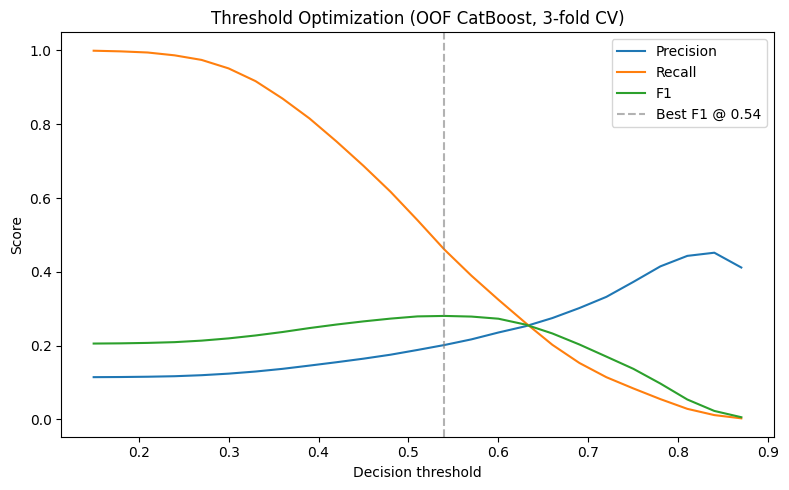

[ 121.6s] Chosen operating threshold: 0.54


In [2]:
thresholds = np.arange(0.15, 0.9, 0.03)
thr_rows = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    thr_rows.append({"threshold": round(t, 2),
                      "precision": precision_score(y_train, pred, zero_division=0),
                      "recall": recall_score(y_train, pred, zero_division=0),
                      "f1": f1_score(y_train, pred, zero_division=0)})
thr_df = pd.DataFrame(thr_rows)
best_f1_row = thr_df.loc[thr_df["f1"].idxmax()]
recall70 = thr_df[thr_df["recall"] >= 0.70].sort_values("precision", ascending=False).head(1)
log("=== THRESHOLD SWEEP ===")
print("Best F1 threshold:\n", best_f1_row)
print("\nHighest-precision threshold with recall>=0.70:\n", recall70)

plt.figure(figsize=(8, 5))
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="F1")
plt.axvline(best_f1_row["threshold"], color="gray", linestyle="--", alpha=0.6, label=f"Best F1 @ {best_f1_row['threshold']}")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.legend(); plt.title("Threshold Optimization (OOF CatBoost, 3-fold CV)")
plt.tight_layout(); plt.savefig(f"{OUT}/09_threshold_sweep.png", dpi=110); plt.show()

CHOSEN_THRESHOLD = float(best_f1_row["threshold"])
log(f"Chosen operating threshold: {CHOSEN_THRESHOLD}")

## 3) HYPERPARAMETER TUNING — small randomized search, 2-fold CV, scored on PR-AUC

In [3]:
import itertools, random
random.seed(42)
param_grid = {"depth": [4, 6, 8], "learning_rate": [0.05, 0.1], "l2_leaf_reg": [1, 5], "iterations": [200, 350]}
all_combos = list(itertools.product(*param_grid.values()))
random.shuffle(all_combos)
search_combos = all_combos[:5]

skf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
tuning_rows = []
for combo in search_combos:
    params = dict(zip(param_grid.keys(), combo))
    fold_pr = []
    for tr, va in skf2.split(X_train, y_train, groups_train):
        Xt_cb, Xv_cb = to_cb(X_train.iloc[tr]), to_cb(X_train.iloc[va])
        yt, yv = y_train.iloc[tr], y_train.iloc[va]
        pw = (yt == 0).sum() / (yt == 1).sum()
        cb = CatBoostClassifier(**params, eval_metric="AUC", scale_pos_weight=pw, random_seed=42, verbose=False)
        cb.fit(Xt_cb, yt, cat_features=cat_idx)
        fold_pr.append(average_precision_score(yv, cb.predict_proba(Xv_cb)[:, 1]))
    tuning_rows.append({**params, "mean_PR_AUC": np.mean(fold_pr)})
    log(f"Tuning combo {params} -> PR-AUC {np.mean(fold_pr):.4f}")

tuning_df = pd.DataFrame(tuning_rows).sort_values("mean_PR_AUC", ascending=False)
log("=== HYPERPARAMETER SEARCH RESULTS ===")
print(tuning_df.to_string(index=False))
tuning_df.to_csv(f"{OUT}/hyperparam_search.csv", index=False)

best_params = tuning_df.iloc[0][list(param_grid.keys())].to_dict()
best_params = {"depth": int(best_params["depth"]), "learning_rate": float(best_params["learning_rate"]),
                "l2_leaf_reg": int(best_params["l2_leaf_reg"]), "iterations": int(best_params["iterations"])}
log(f"Best hyperparameters: {best_params}")

[ 181.1s] Tuning combo {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 350} -> PR-AUC 0.2155


[ 223.4s] Tuning combo {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 350} -> PR-AUC 0.2161


[ 265.9s] Tuning combo {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200} -> PR-AUC 0.2198


[ 349.9s] Tuning combo {'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 350} -> PR-AUC 0.2108


[ 409.6s] Tuning combo {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 350} -> PR-AUC 0.2164


[ 409.6s] === HYPERPARAMETER SEARCH RESULTS ===


 depth  learning_rate  l2_leaf_reg  iterations  mean_PR_AUC
     8           0.05            5         200     0.219846
     6           0.10            1         350     0.216431
     4           0.10            1         350     0.216061
     6           0.10            5         350     0.215526
     8           0.10            5         350     0.210790
[ 409.6s] Best hyperparameters: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200}


## 4) FEATURE RE-SELECTION — drop lowest-importance features, compare 2-fold CV PR-AUC

In [4]:
pw_full = (y_train == 0).sum() / (y_train == 1).sum()
cb_full = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw_full, random_seed=42, verbose=False)
cb_full.fit(X_train_cb, y_train, cat_features=cat_idx)
importance = pd.Series(cb_full.get_feature_importance(), index=X_train_cb.columns).sort_values(ascending=False)
log("Full-feature importance:")
print(importance)

low_importance = importance.tail(4).index.tolist()
log(f"Candidates to drop (lowest importance): {low_importance}")

reduced_features = [c for c in feature_cols if c not in low_importance]
reduced_categorical = [c for c in model_categorical if c in reduced_features]
reduced_cat_idx = [i for i, c in enumerate(reduced_features) if c in reduced_categorical]

fold_pr_full, fold_pr_reduced = [], []
for tr, va in skf2.split(X_train, y_train, groups_train):
    yt, yv = y_train.iloc[tr], y_train.iloc[va]
    pw = (yt == 0).sum() / (yt == 1).sum()

    Xt_full, Xv_full = to_cb(X_train.iloc[tr]), to_cb(X_train.iloc[va])
    cb_a = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw, random_seed=42, verbose=False)
    cb_a.fit(Xt_full, yt, cat_features=cat_idx)
    fold_pr_full.append(average_precision_score(yv, cb_a.predict_proba(Xv_full)[:, 1]))

    Xt_red, Xv_red = to_cb(X_train.iloc[tr][reduced_features]), to_cb(X_train.iloc[va][reduced_features])
    cb_b = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw, random_seed=42, verbose=False)
    cb_b.fit(Xt_red, yt, cat_features=reduced_cat_idx)
    fold_pr_reduced.append(average_precision_score(yv, cb_b.predict_proba(Xv_red)[:, 1]))

log(f"Full feature set PR-AUC:    {np.mean(fold_pr_full):.4f}")
log(f"Reduced feature set PR-AUC: {np.mean(fold_pr_reduced):.4f}")

if np.mean(fold_pr_reduced) >= np.mean(fold_pr_full) - 0.002:
    FINAL_FEATURES, FINAL_CAT_IDX = reduced_features, reduced_cat_idx
    log("Decision: keep REDUCED feature set (comparable performance, simpler model).")
else:
    FINAL_FEATURES, FINAL_CAT_IDX = feature_cols, cat_idx
    log("Decision: keep FULL feature set (dropping features hurt performance).")

[ 447.5s] Full-feature importance:


discharge_disposition_grp    15.867719
number_inpatient             13.431382
medical_specialty_grp         6.497464
diag_1_group                  6.474078
total_prior_visits            5.558849
age                           5.044755
number_diagnoses              4.741613
A1Cresult                     4.371752
admission_type                3.960328
time_in_hospital              3.950879
num_medications               3.346439
insulin                       3.299290
admission_source_grp          3.279887
num_meds_active               3.152810
race                          3.096084
num_lab_procedures            3.041319
gender                        2.972528
diabetesMed                   2.080490
number_emergency              1.418144
number_outpatient             1.298742
num_procedures                1.261247
num_med_changes               0.936779
change                        0.917422
dtype: float64
[ 447.5s] Candidates to drop (lowest importance): ['number_outpatient', 'num_procedures'

[ 530.1s] Full feature set PR-AUC:    0.2198


[ 530.1s] Reduced feature set PR-AUC: 0.2207


[ 530.1s] Decision: keep REDUCED feature set (comparable performance, simpler model).


## 5) LOCK FINAL MODEL — retrain on full train set, evaluate ONCE on held-out test

In [5]:
X_train_final = to_cb(X_train[FINAL_FEATURES])
X_test_final = to_cb(X_test[FINAL_FEATURES])
pw_final = (y_train == 0).sum() / (y_train == 1).sum()
final_model = CatBoostClassifier(**best_params, eval_metric="AUC", scale_pos_weight=pw_final, random_seed=42, verbose=False)
final_model.fit(X_train_final, y_train, cat_features=FINAL_CAT_IDX)

final_proba_test = final_model.predict_proba(X_test_final)[:, 1]
final_pred_test = (final_proba_test >= CHOSEN_THRESHOLD).astype(int)

log("=== FINAL MODEL — HELD-OUT TEST SET (evaluated once) ===")
print("Params:", best_params, "| Threshold:", CHOSEN_THRESHOLD, "| Features:", len(FINAL_FEATURES))
print("ROC-AUC:", round(roc_auc_score(y_test, final_proba_test), 4))
print("PR-AUC :", round(average_precision_score(y_test, final_proba_test), 4))
print(classification_report(y_test, final_pred_test, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, final_pred_test))

final_summary = {
    "best_params": best_params, "chosen_threshold": CHOSEN_THRESHOLD, "final_features": FINAL_FEATURES,
    "test_roc_auc": float(roc_auc_score(y_test, final_proba_test)),
    "test_pr_auc": float(average_precision_score(y_test, final_proba_test)),
    "test_precision": float(precision_score(y_test, final_pred_test, zero_division=0)),
    "test_recall": float(recall_score(y_test, final_pred_test, zero_division=0)),
    "test_f1": float(f1_score(y_test, final_pred_test, zero_division=0)),
}
with open(f"{OUT}/final_model_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)
log("Saved final_model_summary.json")

[ 566.7s] === FINAL MODEL — HELD-OUT TEST SET (evaluated once) ===


Params: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200} | Threshold: 0.54 | Features: 19
ROC-AUC: 0.6699
PR-AUC : 0.2285
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     17586
           1       0.20      0.47      0.28      2216

    accuracy                           0.72     19802
   macro avg       0.56      0.61      0.55     19802
weighted avg       0.84      0.72      0.77     19802

Confusion matrix:
 [[13271  4315]
 [ 1165  1051]]
[ 566.7s] Saved final_model_summary.json


## 6) RE-GENERATE PREDICTIONS + RISK TIERS (full dataset, final model, chosen threshold)

In [6]:
X_all_final = to_cb(pd.concat([X_train[FINAL_FEATURES], X_test[FINAL_FEATURES]], ignore_index=True))
full_idx = list(train_idx) + list(test_idx)
final_proba_all = final_model.predict_proba(X_all_final)[:, 1]

powerbi_df = df.loc[full_idx, ["encounter_id", "patient_nbr", "age", "gender", "race",
                                "admission_type", "discharge_disposition", "admission_source",
                                "time_in_hospital", "num_medications", "number_diagnoses"]].copy()
powerbi_df["actual_readmission"] = df.loc[full_idx, "early_readmission"].values
powerbi_df["readmission_probability"] = final_proba_all
powerbi_df["predicted_readmission"] = (powerbi_df["readmission_probability"] >= CHOSEN_THRESHOLD).astype(int)
powerbi_df["set"] = ["train"] * len(train_idx) + ["test"] * len(test_idx)

q1, q2 = powerbi_df["readmission_probability"].quantile([0.5, 0.85])
def risk_level(p):
    if p < q1: return "Low"
    if p < q2: return "Medium"
    return "High"
powerbi_df["risk_level"] = powerbi_df["readmission_probability"].apply(risk_level)

log("Final risk tier counts:")
print(powerbi_df["risk_level"].value_counts())
powerbi_df.to_csv(f"{OUT}/readmission_predictions_final.csv", index=False)
log("Saved outputs/readmission_predictions_final.csv (tuned model, optimized threshold)")
log("MODEL IMPROVEMENT COMPLETE.")

[ 567.3s] Final risk tier counts:


risk_level
Low       49671
Medium    34770
High      14902
Name: count, dtype: int64


[ 567.8s] Saved outputs/readmission_predictions_final.csv (tuned model, optimized threshold)


[ 567.8s] MODEL IMPROVEMENT COMPLETE.
